# Credit Card Fraud Detection - Exploratory Data Analysis

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

Standard libraries are imported for data analysis, visualization, and numerical operations. These tools support exploratory analysis and fraud pattern detection.

In [20]:
credit_df = pd.read_csv("../data/raw/creditcard.csv")
credit_df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


The dataset contains anonymized credit card transactions with PCA-transformed features (V1–V28), transaction time, amount, and fraud label

In [21]:
credit_df.shape
credit_df.info()
credit_df.describe()
credit_df.isnull().sum()
credit_df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

np.int64(1081)

The dataset contains a large number of anonymized features with no missing values, suitable for fraud classification modeling.

In [13]:
credit_df['Class'].value_counts()
credit_df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

The dataset is checked for structure, data types, missing values, and duplicates. The data is clean with no missing values, which simplifies preprocessing.

In [22]:
credit_df['Class'].value_counts()
credit_df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

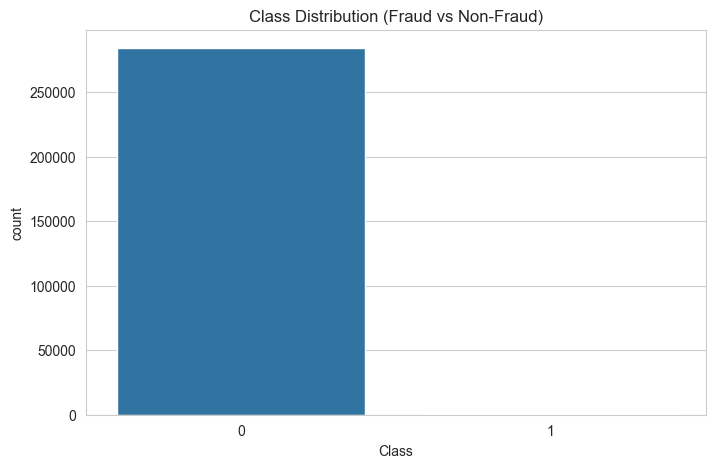

In [14]:
sns.countplot(x='Class', data=credit_df)
plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.show()

The dataset is extremely imbalanced, with fraud cases representing less than 1% of total transactions. This makes accuracy unreliable and requires specialized metrics.

In [15]:
credit_df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

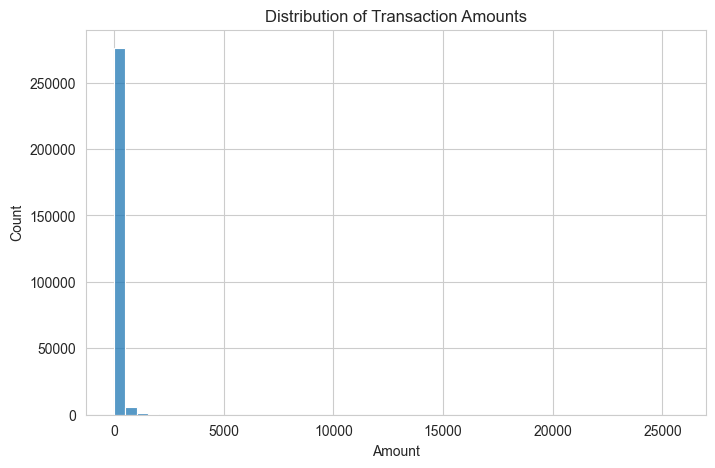

In [16]:
sns.histplot(credit_df['Amount'], bins=50)
plt.title("Distribution of Transaction Amounts")
plt.show()

Transaction amounts are highly skewed, with most values concentrated in lower ranges.

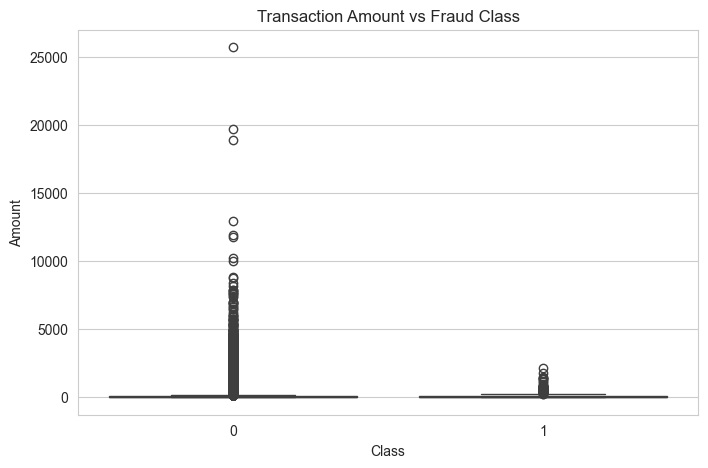

In [17]:
sns.boxplot(x='Class', y='Amount', data=credit_df)
plt.title("Transaction Amount vs Fraud Class")
plt.show()

Fraudulent transactions show different spending patterns compared to legitimate ones, indicating behavioral differences.

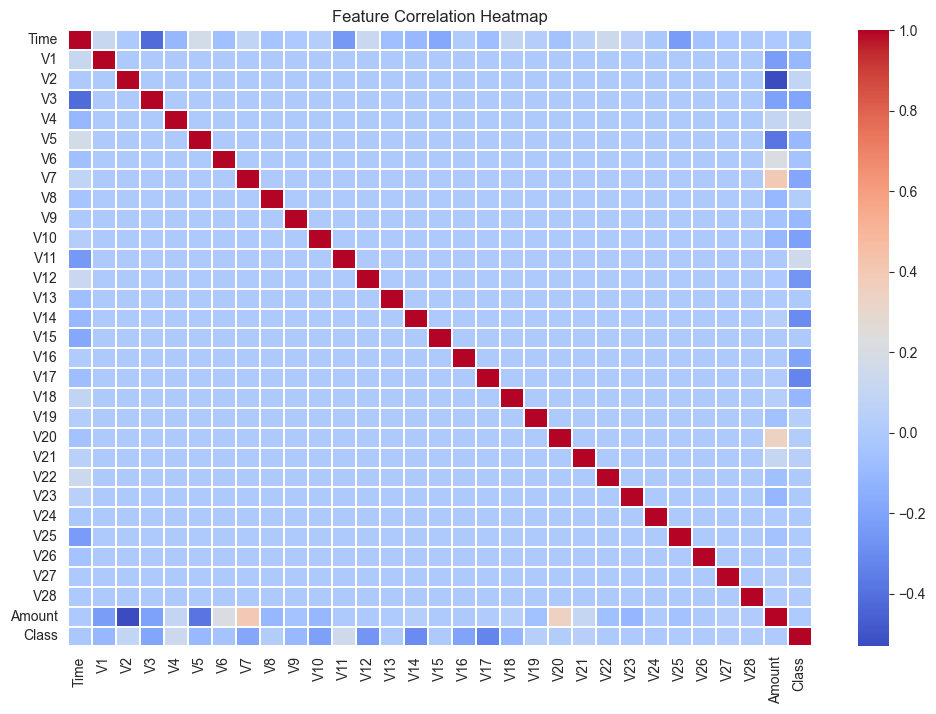

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(credit_df.corr(), cmap='coolwarm', linewidths=0.2)
plt.title("Feature Correlation Heatmap")
plt.show()

PCA-transformed features show weak but meaningful relationships useful for detecting anomalies in transaction behavior.

In [24]:
credit_df['log_amount'] = np.log1p(credit_df['Amount'])

Log transformation reduces skewness in transaction amounts, improving model stability.

In [25]:
df = credit_df.copy()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,log_amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539


Final dataset copy is created for modeling to preserve original data integrity.

## Key Insights

- Dataset is extremely imbalanced (<1% fraud cases)
- No missing values or duplicates were found
- Transaction amounts are highly skewed
- PCA features contain hidden fraud patterns
- Requires imbalance-aware modeling (SMOTE, F1-score, AUC-PR)

## Class Imbalance Handling Strategy

Both datasets exhibit significant class imbalance, where fraudulent transactions represent only a small proportion of observations.

To address this issue during model development, SMOTE (Synthetic Minority Over-sampling Technique) will be applied only to the training data after performing a stratified train-test split. This prevents information leakage from the training set into the test set and ensures that evaluation metrics reflect real-world performance.

F1-score and AUC-PR will be prioritized over accuracy because they provide more reliable evaluation for highly imbalanced classification problems.
